In [1]:
import pandas as pd
import seaborn as sns

df = pd.read_csv(
    "d:/HK3 - năm 3/Đồ Án/Code/vietnam-transportation-cpi-forecasting/data/processed/model_dataset.csv"
)

df.head()

,MonthYear,CPI,RON95,Diesel,Brent,WTI,USD_VND,Dummy_Tet,Dummy_Covid
0,2012-01,0.66,21800.00,21100.00,110.69,100.27,20828.0,1,0
1,2012-02,0.23,21800.00,21100.00,119.33,102.20,20828.0,0,0
2,2012-03,1.08,23090.32,21341.94,125.45,106.16,20828.0,0,0
3,2012-04,2.67,23400.00,21400.00,119.75,103.32,20828.0,0,0
4,2012-05,1.32,23522.58,21432.26,110.34,94.66,20828.0,0,0


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 156 entries, 0 to 155
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MonthYear    156 non-null    str    
 1   CPI          156 non-null    float64
 2   RON95        156 non-null    float64
 3   Diesel       156 non-null    float64
 4   Brent        156 non-null    float64
 5   WTI          156 non-null    float64
 6   USD_VND      156 non-null    float64
 7   Dummy_Tet    156 non-null    int64  
 8   Dummy_Covid  156 non-null    int64  
dtypes: float64(6), int64(2), str(1)
memory usage: 12.2 KB


## 1. Kiểm tra và mô tả dữ liệu

Trước khi tiến hành phân tích khám phá, dữ liệu được kiểm tra về cấu trúc, kiểu dữ liệu và số lượng quan sát. Sau đó, thống kê mô tả được thực hiện đối với các biến định lượng gồm CPI giao thông, giá xăng RON95, giá dầu Diesel, giá dầu Brent, WTI và tỷ giá USD/VND.

Các biến giả `Dummy_Tet` và `Dummy_Covid` không được đưa vào bảng thống kê mô tả chung mà sẽ được phân tích riêng theo từng nhóm thời kỳ.

In [3]:
df[
    ["CPI", "RON95", "Diesel", "Brent", "WTI", "USD_VND"]
].describe().round(2)

,CPI,RON95,Diesel,Brent,WTI,USD_VND
count,156.00,156.00,156.00,156.00,156.00,156.00
mean,0.07,20968.26,17960.32,75.47,69.70,22472.21
std,2.30,3624.50,3991.21,24.67,21.67,1061.77
min,-13.86,12112.58,9999.68,18.38,16.55,20828.00
25%,-0.92,18451.93,15522.26,56.08,51.30,21458.00
50%,0.17,21301.94,18024.95,74.21,70.18,22624.34
75%,1.25,23650.00,21550.00,95.64,87.63,23192.40
max,6.05,32216.67,28298.00,125.45,114.84,24280.47


In [4]:
df["MonthYear"] = pd.to_datetime(
    df["MonthYear"]
).dt.to_period("M")

df.dtypes

MonthYear      period[M]
CPI              float64
RON95            float64
Diesel           float64
Brent            float64
WTI              float64
USD_VND          float64
Dummy_Tet          int64
Dummy_Covid        int64
dtype: object

## 2. Phân tích diễn biến CPI giao thông theo thời gian

Biểu đồ chuỗi thời gian được sử dụng để quan sát xu hướng và mức độ biến động của CPI nhóm Giao thông trong giai đoạn 2012–2024, qua đó nhận diện các thời kỳ tăng, giảm và những biến động bất thường.

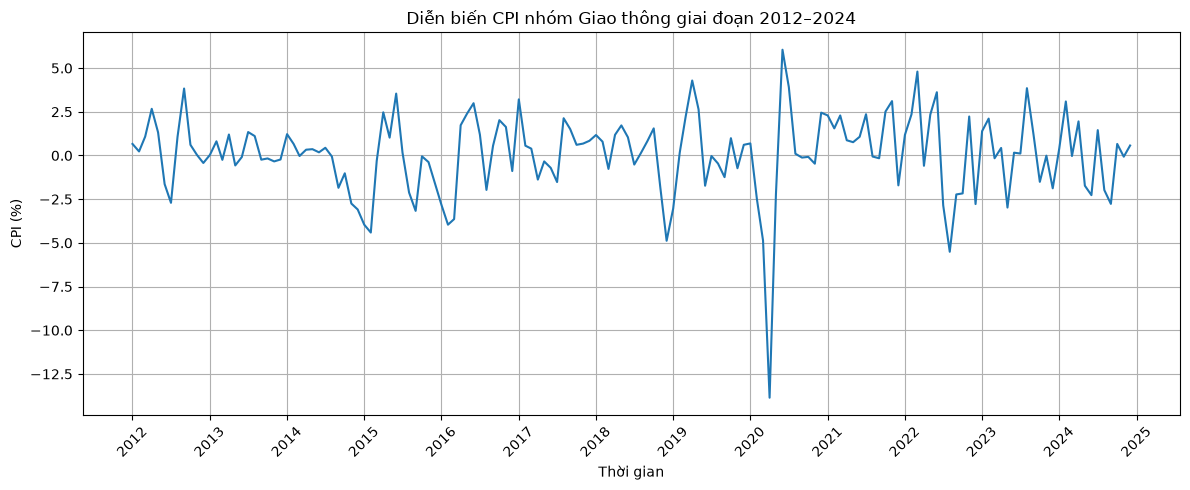

In [5]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(12, 5))

plt.plot(
    df["MonthYear"].dt.to_timestamp(),
    df["CPI"]
)

plt.title("Diễn biến CPI nhóm Giao thông giai đoạn 2012–2024")
plt.xlabel("Thời gian")
plt.ylabel("CPI (%)")

ax = plt.gca()

ax.xaxis.set_major_locator(
    mdates.YearLocator(1)
)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%Y")
)

plt.xticks(rotation=45)     

plt.grid(True)
plt.tight_layout()

plt.show()

### Nhận xét

CPI nhóm Giao thông biến động khá mạnh trong giai đoạn 2012-2024, với nhiều tháng tăng và giảm rõ rệt. Mức biến động không ổn định theo thời gian, cho thấy CPI giao thông chịu ảnh hưởng đáng kể từ các yếu tố liên quan đến giá nhiên liệu, giá dầu thế giới, tỷ giá và các cú sốc đặc biệt như Tết Nguyên đán hoặc Covid-19.

Một số thời kỳ xuất hiện mức giảm sâu hoặc tăng mạnh hơn đáng kể so với các tháng còn lại, do đó cần tiếp tục phân tích mối quan hệ giữa CPI với các biến đầu vào trước khi xây dựng mô hình dự báo.

## 3. Diễn biến giá nhiên liệu trong nước

Biểu đồ thể hiện diễn biến giá xăng RON95 và dầu Diesel trong giai đoạn 2012–2024 nhằm quan sát xu hướng biến động của giá nhiên liệu trong nước và làm cơ sở đánh giá mối liên hệ với CPI nhóm Giao thông.

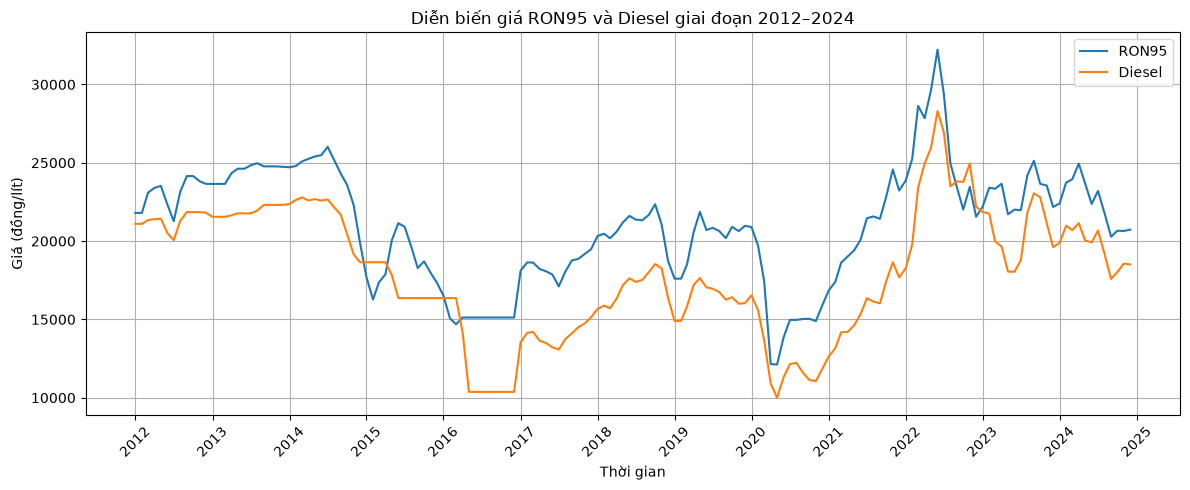

In [6]:
dates = df["MonthYear"].dt.to_timestamp()

plt.figure(figsize=(12, 5))

plt.plot(dates, df["RON95"], label="RON95")
plt.plot(dates, df["Diesel"], label="Diesel")

plt.title("Diễn biến giá RON95 và Diesel giai đoạn 2012–2024")
plt.xlabel("Thời gian")
plt.ylabel("Giá (đồng/lít)")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

In [7]:
for col in ["RON95", "Diesel"]:
    max_idx = df[col].idxmax()
    min_idx = df[col].idxmin()

    print(f"{col} cao nhất:")
    print(
        df.loc[max_idx, "MonthYear"],
        "-",
        round(df.loc[max_idx, col], 2)
    )

    print(f"{col} thấp nhất:")
    print(
        df.loc[min_idx, "MonthYear"],
        "-",
        round(df.loc[min_idx, col], 2)
    )

    print()

RON95 cao nhất:
2022-06 - 32216.67
RON95 thấp nhất:
2020-05 - 12112.58

Diesel cao nhất:
2022-06 - 28298.0
Diesel thấp nhất:
2020-05 - 9999.68



### Nhận xét

Giá xăng RON95 và dầu Diesel có xu hướng biến động khá tương đồng trong giai đoạn 2012–2024. Hai mặt hàng nhìn chung cùng tăng hoặc cùng giảm theo thời gian, cho thấy sự đồng bộ trong biến động giá nhiên liệu trong nước.

Giai đoạn 2015–2016, giá RON95 và Diesel giảm đáng kể so với những năm trước. Đến năm 2020, cả hai tiếp tục giảm mạnh và đạt mức thấp nhất vào tháng 05/2020, với RON95 khoảng 12.112,58 đồng/lít và Diesel khoảng 9.999,68 đồng/lít.

Từ năm 2021, giá nhiên liệu tăng trở lại và tăng mạnh trong năm 2022. Cả RON95 và Diesel đều đạt mức cao nhất vào tháng 06/2022, lần lượt khoảng 32.216,67 đồng/lít và 28.298,00 đồng/lít. Sau giai đoạn này, giá có xu hướng giảm nhưng vẫn duy trì mức biến động tương đối lớn trong các năm 2023–2024.

Nhìn chung, RON95 và Diesel có mức độ biến động đáng kể theo thời gian và có khả năng liên quan trực tiếp đến sự biến động của CPI nhóm Giao thông. Mối quan hệ này sẽ được xem xét cụ thể hơn thông qua phân tích tương quan và độ trễ ở các bước tiếp theo.

## 4. Diễn biến giá dầu thô thế giới

Biểu đồ thể hiện diễn biến giá dầu Brent và WTI trong giai đoạn 2012–2024 nhằm quan sát xu hướng biến động của thị trường dầu thô thế giới và làm cơ sở đánh giá mối liên hệ với CPI nhóm Giao thông.

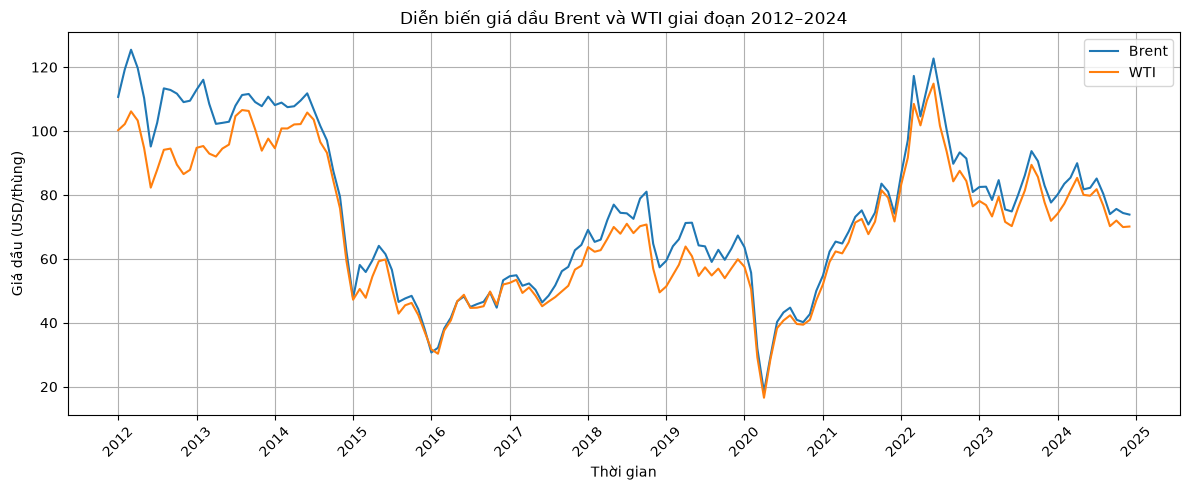

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["MonthYear"].dt.to_timestamp(),
    df["Brent"],
    label="Brent"
)

plt.plot(
    df["MonthYear"].dt.to_timestamp(),
    df["WTI"],
    label="WTI"
)

plt.title("Diễn biến giá dầu Brent và WTI giai đoạn 2012–2024")
plt.xlabel("Thời gian")
plt.ylabel("Giá dầu (USD/thùng)")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.show()

In [9]:
for col in ["Brent", "WTI"]:
    max_idx = df[col].idxmax()
    min_idx = df[col].idxmin()

    print(f"{col} cao nhất:")
    print(
        df.loc[max_idx, "MonthYear"],
        "-",
        round(df.loc[max_idx, col], 2)
    )

    print(f"{col} thấp nhất:")
    print(
        df.loc[min_idx, "MonthYear"],
        "-",
        round(df.loc[min_idx, col], 2)
    )

    print()

Brent cao nhất:
2012-03 - 125.45
Brent thấp nhất:
2020-04 - 18.38

WTI cao nhất:
2022-06 - 114.84
WTI thấp nhất:
2020-04 - 16.55



### Nhận xét

Giá dầu Brent và WTI có xu hướng biến động tương đối đồng bộ trong giai đoạn 2012–2024. Hai chuỗi nhìn chung cùng tăng hoặc cùng giảm theo thời gian, cho thấy sự liên kết chặt chẽ giữa hai chuẩn giá dầu thô quốc tế.

Trong giai đoạn 2014–2016, giá Brent và WTI giảm mạnh so với mức cao của các năm trước. Đặc biệt, cả hai cùng đạt mức thấp nhất vào tháng 04/2020, với Brent khoảng 18,38 USD/thùng và WTI khoảng 16,55 USD/thùng.

Sau năm 2020, giá dầu phục hồi rõ rệt và tăng mạnh trong giai đoạn 2021–2022. WTI đạt mức cao nhất trong giai đoạn nghiên cứu vào tháng 06/2022 với khoảng 114,84 USD/thùng. Trong khi đó, Brent đạt mức cao nhất vào tháng 03/2012 với khoảng 125,45 USD/thùng.

Từ năm 2023 đến 2024, giá Brent và WTI giảm so với đỉnh năm 2022 nhưng vẫn duy trì mức biến động đáng kể. Sự biến động của giá dầu thế giới có thể tác động gián tiếp đến CPI nhóm Giao thông thông qua giá nhiên liệu trong nước, do đó mối quan hệ này sẽ được xem xét thêm trong phân tích tương quan và độ trễ.

## 5. Diễn biến tỷ giá USD/VND

Biểu đồ thể hiện diễn biến tỷ giá USD/VND trong giai đoạn 2012–2024 nhằm quan sát xu hướng biến động của tỷ giá và làm cơ sở đánh giá mối liên hệ với CPI nhóm Giao thông.

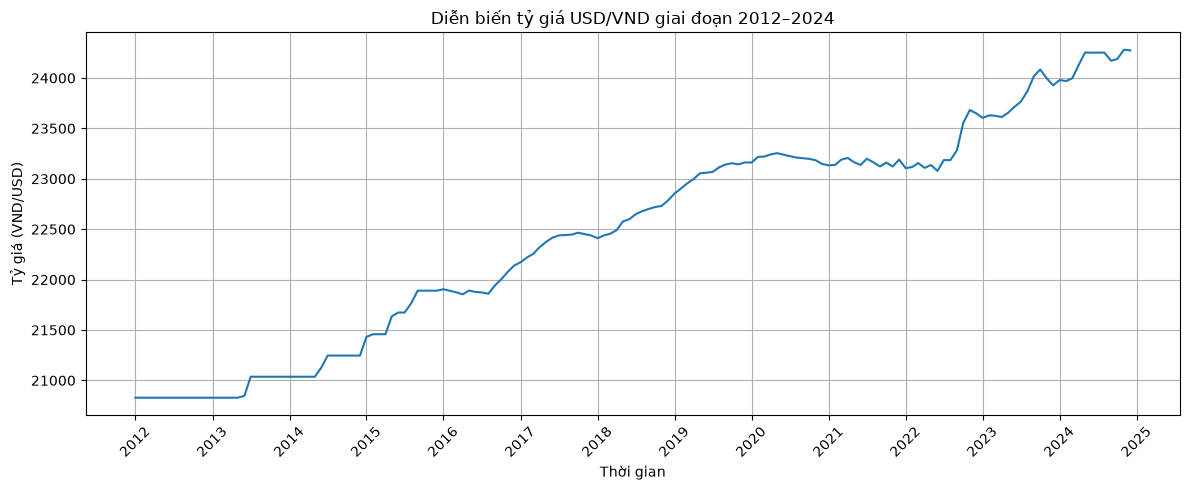

In [10]:
plt.figure(figsize=(12, 5))

plt.plot(
    df["MonthYear"].dt.to_timestamp(),
    df["USD_VND"]
)

plt.title("Diễn biến tỷ giá USD/VND giai đoạn 2012–2024")
plt.xlabel("Thời gian")
plt.ylabel("Tỷ giá (VND/USD)")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()

plt.show()

In [11]:
for col in ["USD_VND"]:
    max_idx = df[col].idxmax()
    min_idx = df[col].idxmin()

    print(f"{col} cao nhất:")
    print(
        df.loc[max_idx, "MonthYear"],
        "-",
        round(df.loc[max_idx, col], 2)
    )

    print(f"{col} thấp nhất:")
    print(
        df.loc[min_idx, "MonthYear"],
        "-",
        round(df.loc[min_idx, col], 2)
    )

    print()

USD_VND cao nhất:
2024-11 - 24280.47
USD_VND thấp nhất:
2012-01 - 20828.0



### Nhận xét

Tỷ giá USD/VND có xu hướng tăng tương đối rõ trong giai đoạn 2012–2024. So với các biến giá nhiên liệu và giá dầu thế giới, tỷ giá biến động theo hướng ổn định hơn và chủ yếu thể hiện xu hướng tăng dài hạn.

Trong giai đoạn đầu, tỷ giá duy trì ở mức thấp và khá ổn định. Mức thấp nhất trong toàn bộ giai đoạn nghiên cứu được ghi nhận vào tháng 01/2012, khoảng 20.828 VND/USD. Từ các năm sau, tỷ giá tăng dần qua nhiều giai đoạn và có một số thời kỳ tương đối ổn định.

Từ năm 2022 trở đi, tỷ giá có xu hướng tăng rõ hơn và đạt mức cao nhất vào tháng 11/2024, khoảng 24.280,47 VND/USD.

Nhìn chung, USD/VND thể hiện xu hướng tăng trong dài hạn. Biến động tỷ giá có thể ảnh hưởng đến chi phí nhập khẩu nhiên liệu và qua đó có khả năng tác động gián tiếp đến CPI nhóm Giao thông. Mối quan hệ này sẽ được xem xét thêm thông qua phân tích tương quan và độ trễ.

## 6. Phân tích ảnh hưởng của Tết Nguyên đán

Biến `Dummy_Tet` được sử dụng để phân biệt các tháng chịu tác động chính của Tết Nguyên đán với các tháng còn lại. Phân tích này nhằm xem xét liệu CPI nhóm Giao thông có khác biệt đáng kể giữa tháng Tết và tháng không Tết hay không.

In [12]:
tet_summary = (
    df.groupby("Dummy_Tet")["CPI"]
    .agg(["count", "mean", "std", "min", "max"])
    .round(2)
)

tet_summary.index = ["Không Tết", "Tết"]

tet_summary

,count,mean,std,min,max
Không Tết,143,0.02,2.31,-13.86,6.05
Tết,13,0.58,2.31,-4.41,3.21


<Figure size 700x500 with 0 Axes>

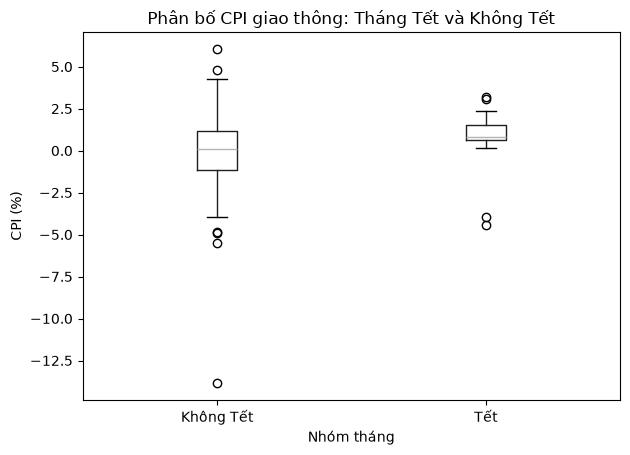

In [13]:
plt.figure(figsize=(7, 5))

df.boxplot(
    column="CPI",
    by="Dummy_Tet"
)

plt.title("Phân bố CPI giao thông: Tháng Tết và Không Tết")
plt.suptitle("")
plt.xlabel("Nhóm tháng")
plt.ylabel("CPI (%)")

plt.xticks(
    [1, 2],
    ["Không Tết", "Tết"]
)

plt.grid(False)
plt.tight_layout()
plt.show()

### Nhận xét

CPI nhóm Giao thông trong các tháng Tết có xu hướng cao hơn so với các tháng không Tết. CPI trung bình trong tháng Tết đạt khoảng **0,58%**, trong khi các tháng không Tết chỉ khoảng **0,02%**.

Boxplot cho thấy phần lớn CPI trong các tháng Tết tập trung ở vùng giá trị dương, trong khi nhóm không Tết có mức phân tán rộng hơn và xuất hiện nhiều biến động mạnh theo cả chiều tăng và giảm.

Tuy nhiên, nhóm tháng Tết chỉ gồm **13 quan sát**, nhỏ hơn đáng kể so với 143 quan sát của nhóm không Tết. Vì vậy, kết quả trên mới mang tính mô tả và chưa đủ để khẳng định Tết Nguyên đán tạo ra sự khác biệt có ý nghĩa thống kê đối với CPI giao thông.

## 7. Phân tích ảnh hưởng của Covid-19

Biến `Dummy_Covid` được sử dụng để phân biệt giai đoạn chịu ảnh hưởng của Covid-19 với các giai đoạn còn lại. Phân tích này nhằm xem xét sự khác biệt về mức độ và phạm vi biến động của CPI nhóm Giao thông giữa hai thời kỳ.

In [14]:
covid_summary = (
    df.groupby("Dummy_Covid")["CPI"]
    .agg(["count", "mean", "std", "min", "max"])
    .round(2)
)

covid_summary.index = ["Ngoài Covid", "Covid"]

covid_summary

,count,mean,std,min,max
Ngoài Covid,134,0.06,1.96,-5.51,4.80
Covid,22,0.12,3.86,-13.86,6.05


<Figure size 700x500 with 0 Axes>

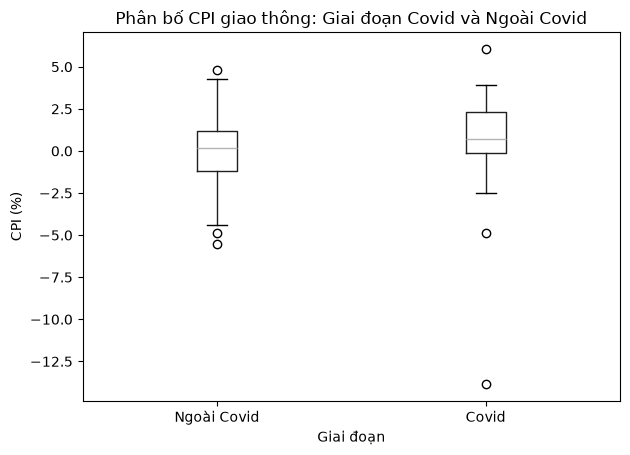

In [15]:
plt.figure(figsize=(7, 5))

df.boxplot(
    column="CPI",
    by="Dummy_Covid"
)

plt.title("Phân bố CPI giao thông: Giai đoạn Covid và Ngoài Covid")
plt.suptitle("")
plt.xlabel("Giai đoạn")
plt.ylabel("CPI (%)")

plt.xticks(
    [1, 2],
    ["Ngoài Covid", "Covid"]
)

plt.grid(False)
plt.tight_layout()
plt.show()

### Nhận xét

Trong giai đoạn Covid-19, CPI nhóm Giao thông không có mức trung bình cao hơn đáng kể so với giai đoạn ngoài Covid. CPI trung bình trong giai đoạn Covid đạt khoảng **0,12%**, trong khi giai đoạn ngoài Covid đạt khoảng **0,06%**.

Tuy nhiên, mức độ biến động của CPI trong giai đoạn Covid lớn hơn rõ rệt. Độ lệch chuẩn của CPI trong giai đoạn Covid đạt **3,86**, gần gấp đôi so với mức **1,96** của giai đoạn ngoài Covid. Điều này cho thấy CPI giao thông trong thời kỳ Covid có mức độ bất ổn cao hơn.

Boxplot cũng cho thấy giai đoạn Covid xuất hiện nhiều giá trị bất thường, trong đó có mức giảm sâu tới **-13,86%** và mức tăng cao khoảng **6,05%**. Trong khi đó, giai đoạn ngoài Covid có phạm vi biến động hẹp hơn, từ khoảng **-5,51% đến 4,80%**.

Nhìn chung, Covid-19 không làm thay đổi đáng kể mức CPI giao thông trung bình, nhưng có liên quan đến sự gia tăng mạnh về mức độ biến động của CPI. Vì vậy, biến `Dummy_Covid` được giữ lại để xem xét ảnh hưởng của giai đoạn Covid trong các bước phân tích và xây dựng mô hình tiếp theo.

## 8. Phân tích tương quan giữa các biến

Để phù hợp với CPI được biểu diễn dưới dạng % thay đổi theo tháng, các biến RON95, Diesel, Brent, WTI và USD/VND cũng được chuyển sang tỷ lệ thay đổi theo tháng trước khi tính tương quan.

Hệ số tương quan nằm trong khoảng từ `-1` đến `1`:

- Giá trị gần `1`: hai biến có xu hướng tăng giảm cùng chiều mạnh.
- Giá trị gần `-1`: hai biến có xu hướng biến động ngược chiều mạnh.
- Giá trị gần `0`: mối quan hệ tuyến tính giữa hai biến yếu.

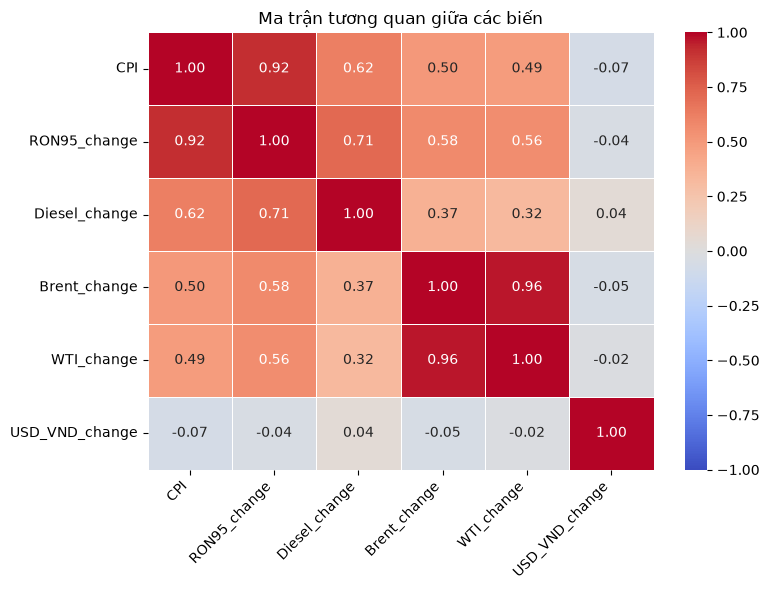

In [16]:
df["RON95_change"] = df["RON95"].pct_change() * 100
df["Diesel_change"] = df["Diesel"].pct_change() * 100
df["Brent_change"] = df["Brent"].pct_change() * 100
df["WTI_change"] = df["WTI"].pct_change() * 100
df["USD_VND_change"] = df["USD_VND"].pct_change() * 100 

corr_change = df[
    [
        "CPI",
        "RON95_change",
        "Diesel_change",
        "Brent_change",
        "WTI_change",
        "USD_VND_change"
    ]
].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_change,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    annot=True,      # hiện số trong ô
    fmt=".2f",       # làm tròn 2 chữ số
    linewidths=0.5,
    cbar=True
)

plt.title("Ma trận tương quan giữa các biến")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Nhận xét

CPI giao thông có tương quan dương mạnh nhất với biến động giá **RON95 (0,92)** và **Diesel (0,62)**. Biến động giá dầu **Brent (0,50)** và **WTI (0,49)** có tương quan ở mức trung bình, trong khi biến động **USD/VND (-0,07)** gần như không có tương quan tuyến tính với CPI trong cùng tháng.

Ngoài ra, **Brent và WTI có tương quan rất cao (0,96)**, cho thấy hai biến có diễn biến gần giống nhau và cần lưu ý khi đưa đồng thời vào mô hình.

Kết quả cho thấy biến động giá nhiên liệu trong nước có mối liên hệ rõ hơn với CPI giao thông. Tuy nhiên, tương quan không phản ánh quan hệ nhân quả và cần tiếp tục kiểm tra ảnh hưởng theo độ trễ.

## 9. Phân tích độ trễ giữa CPI và các biến giải thích

Phân tích độ trễ được thực hiện nhằm kiểm tra liệu sự thay đổi của các biến giải thích ở những tháng trước có liên quan đến CPI nhóm Giao thông ở tháng hiện tại hay không.

Các biến giá được sử dụng dưới dạng **tỷ lệ thay đổi theo tháng** để phù hợp với CPI, vốn cũng được biểu diễn dưới dạng % thay đổi so với tháng trước.

### 9.1. Phân tích độ trễ của giá RON95

Tiến hành xem xét mối liên hệ giữa biến động giá RON95 và CPI nhóm Giao thông tại các độ trễ từ **0 đến 6 tháng**.

Trong đó:

- Lag 0: biến động giá RON95 trong cùng tháng với CPI.
- Lag 1: biến động giá RON95 của tháng trước.
- Lag 2–6: biến động giá RON95 trước CPI từ 2 đến 6 tháng.

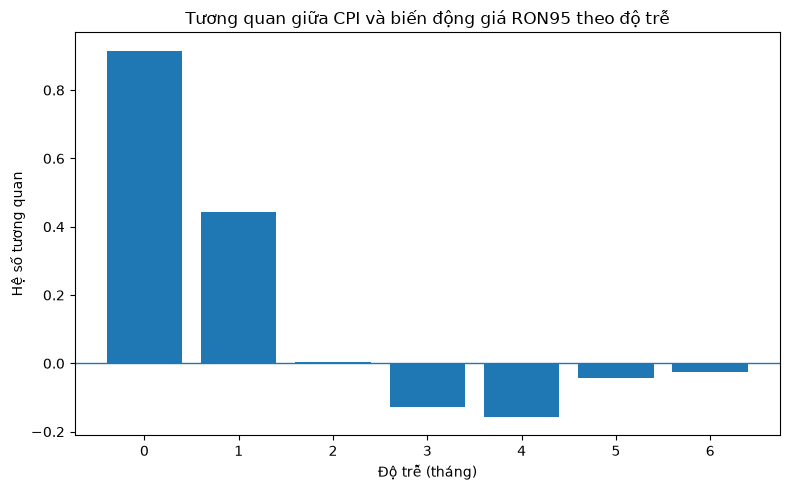

In [17]:
df["RON95_change"] = (
    df["RON95"]
    .pct_change() * 100
)

lags = range(0, 7)

corr_values = [
    df["CPI"].corr(df["RON95_change"].shift(lag))
    for lag in lags
]

plt.figure(figsize=(8, 5))

plt.bar(lags, corr_values)

plt.axhline(y=0, linewidth=1)

plt.xlabel("Độ trễ (tháng)")
plt.ylabel("Hệ số tương quan")
plt.title("Tương quan giữa CPI và biến động giá RON95 theo độ trễ")

plt.xticks(lags)

plt.tight_layout()
plt.show()

### Nhận xét

Kết quả phân tích độ trễ cho thấy biến động giá RON95 có mối liên hệ mạnh với CPI nhóm Giao thông tại cùng thời điểm. Ở độ trễ 0 tháng, hệ số tương quan đạt khoảng **0,91**, cho thấy khi giá RON95 tăng hoặc giảm trong tháng thì CPI giao thông cũng có xu hướng biến động cùng chiều khá rõ rệt.

Ở độ trễ 1 tháng, hệ số tương quan giảm xuống khoảng **0,44**, cho thấy biến động giá RON95 của tháng trước vẫn có mối liên hệ nhất định với CPI của tháng hiện tại. Tuy nhiên, từ độ trễ 2 tháng trở đi, hệ số tương quan giảm mạnh và chủ yếu dao động quanh mức 0 hoặc âm nhẹ.

Như vậy, trong bộ dữ liệu nghiên cứu, mối liên hệ giữa biến động giá RON95 và CPI giao thông tập trung chủ yếu ở **tháng hiện tại và tháng liền trước**. Kết quả này gợi ý rằng các biến thể hiện mức thay đổi của giá nhiên liệu và các độ trễ ngắn có thể là những đặc trưng đáng xem xét trong bước xây dựng mô hình.

### 9.2. Phân tích độ trễ của giá Diesel

Tiếp tục xem xét mối liên hệ giữa biến động giá Diesel ở các tháng trước và CPI nhóm Giao thông tại tháng hiện tại, với độ trễ từ 0 đến 6 tháng.

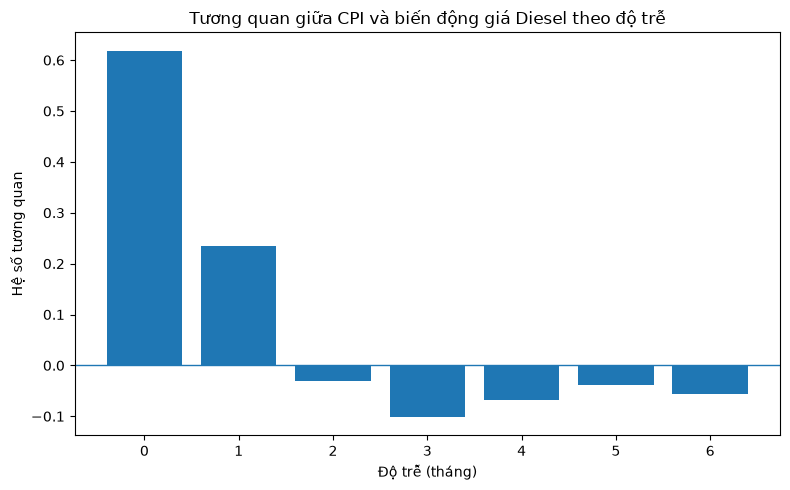

In [18]:
# Tạo biến % thay đổi giá Diesel theo tháng
df["Diesel_change"] = df["Diesel"].pct_change() * 100

lags = range(0, 7)

corr_values = [
    df["CPI"].corr(df["Diesel_change"].shift(lag))
    for lag in lags
]

plt.figure(figsize=(8, 5))

plt.bar(lags, corr_values)
plt.axhline(y=0, linewidth=1)

plt.xlabel("Độ trễ (tháng)")
plt.ylabel("Hệ số tương quan")
plt.title("Tương quan giữa CPI và biến động giá Diesel theo độ trễ")

plt.xticks(lags)
plt.tight_layout()
plt.show()

### Nhận xét

Biến động giá Diesel có tương quan dương khá mạnh với CPI nhóm Giao thông tại **Lag 0**, với hệ số khoảng **0,62**. Điều này cho thấy biến động giá Diesel trong cùng tháng có mối liên hệ đáng kể với biến động CPI giao thông.

Ở **Lag 1**, hệ số tương quan giảm còn khoảng **0,23**, cho thấy ảnh hưởng của giá Diesel tháng trước vẫn còn nhưng yếu hơn rõ rệt.

Từ **Lag 2 đến Lag 6**, hệ số tương quan đều ở mức rất thấp và chủ yếu mang dấu âm, cho thấy mối liên hệ tuyến tính giữa biến động giá Diesel ở các tháng xa hơn và CPI hiện tại là không đáng kể.

Nhìn chung, mối liên hệ giữa biến động giá Diesel và CPI giao thông tập trung chủ yếu ở **tháng hiện tại và tháng liền trước**.

### 9.3. Phân tích độ trễ của giá dầu Brent

Tiến hành xem xét mối liên hệ giữa biến động giá dầu Brent và CPI nhóm Giao thông tại các độ trễ từ **0 đến 6 tháng**.

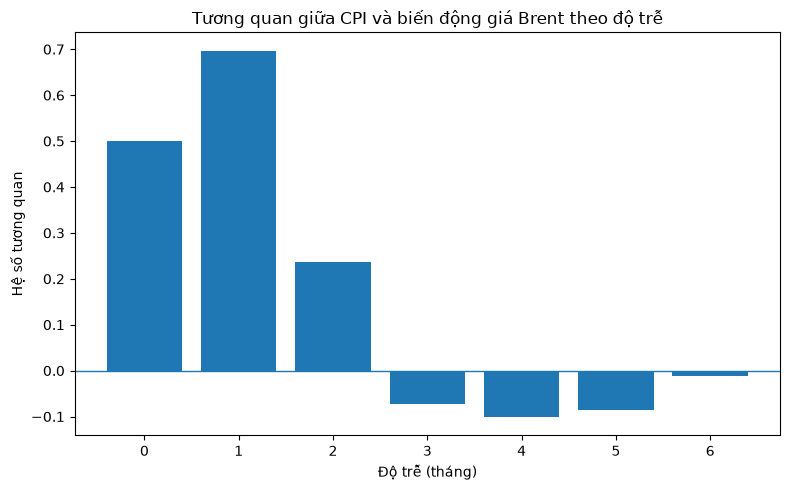

In [19]:
df["Brent_change"] = df["Brent"].pct_change() * 100

lags = range(0, 7)

corr_values = [
    df["CPI"].corr(df["Brent_change"].shift(lag))
    for lag in lags
]

plt.figure(figsize=(8, 5))

plt.bar(lags, corr_values)
plt.axhline(y=0, linewidth=1)

plt.xlabel("Độ trễ (tháng)")
plt.ylabel("Hệ số tương quan")
plt.title("Tương quan giữa CPI và biến động giá Brent theo độ trễ")

plt.xticks(lags)
plt.tight_layout()
plt.show()

### Nhận xét

Biến động giá dầu Brent có tương quan dương với CPI nhóm Giao thông tại **Lag 0**, với hệ số khoảng **0,50**. Tuy nhiên, mức tương quan mạnh nhất xuất hiện tại **Lag 1**, đạt khoảng **0,69**.

Kết quả này cho thấy biến động giá Brent của **tháng trước** có mối liên hệ với CPI giao thông tháng hiện tại mạnh hơn so với biến động Brent trong cùng tháng. Ở **Lag 2**, tương quan vẫn còn ở mức thấp hơn, khoảng **0,24**.

Từ **Lag 3 đến Lag 6**, hệ số tương quan giảm mạnh và dao động gần 0, cho thấy ảnh hưởng theo độ trễ xa hơn là không đáng kể.

Nhìn chung, mối liên hệ giữa biến động giá Brent và CPI giao thông tập trung chủ yếu ở **Lag 0 đến Lag 2**, đặc biệt nổi bật tại **Lag 1**.

### 9.4. Phân tích độ trễ của giá dầu WTI

Tiến hành xem xét mối liên hệ giữa biến động giá dầu WTI và CPI nhóm Giao thông tại các độ trễ từ **0 đến 6 tháng**.

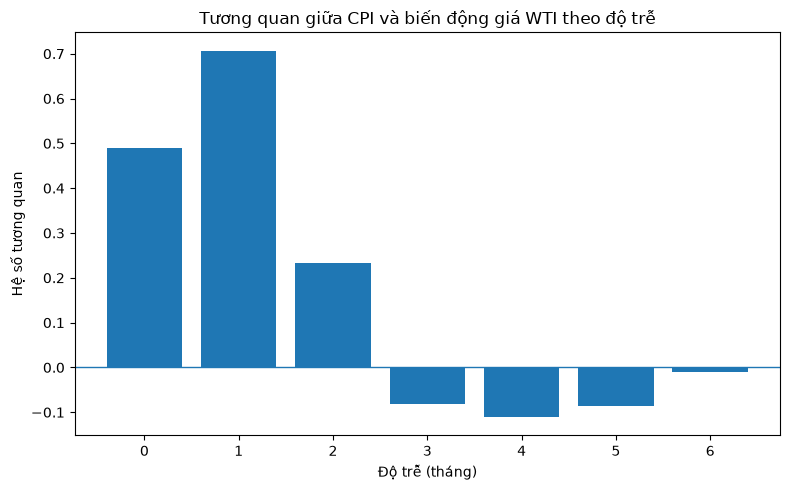

In [20]:
df["WTI_change"] = df["WTI"].pct_change() * 100

lags = range(0, 7)

corr_values = [
    df["CPI"].corr(df["WTI_change"].shift(lag))
    for lag in lags
]

plt.figure(figsize=(8, 5))

plt.bar(lags, corr_values)
plt.axhline(y=0, linewidth=1)

plt.xlabel("Độ trễ (tháng)")
plt.ylabel("Hệ số tương quan")
plt.title("Tương quan giữa CPI và biến động giá WTI theo độ trễ")

plt.xticks(lags)
plt.tight_layout()
plt.show()

### Nhận xét

Biến động giá dầu WTI có tương quan dương với CPI nhóm Giao thông tại **Lag 0**, với hệ số khoảng **0,49**. Mức tương quan mạnh nhất xuất hiện tại **Lag 1**, đạt khoảng **0,70**.

Ở **Lag 2**, hệ số tương quan giảm còn khoảng **0,23**. Từ **Lag 3 đến Lag 6**, tương quan rất yếu và chủ yếu mang dấu âm.

Nhìn chung, ảnh hưởng của biến động giá WTI đến CPI giao thông tập trung chủ yếu trong **tháng hiện tại và tháng liền trước**, trong đó **Lag 1** là độ trễ nổi bật nhất.

### 9.5. Phân tích độ trễ của tỷ giá USD/VND

Tiến hành xem xét mối liên hệ giữa biến động tỷ giá USD/VND và CPI nhóm Giao thông tại các độ trễ từ **0 đến 6 tháng**.

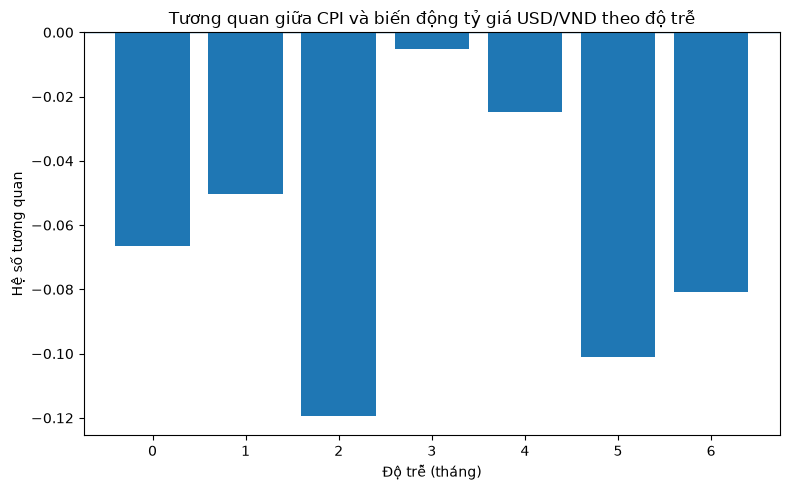

In [21]:
df["USD_VND_change"] = df["USD_VND"].pct_change() * 100

lags = range(0, 7)

corr_values = [
    df["CPI"].corr(df["USD_VND_change"].shift(lag))
    for lag in lags
]

plt.figure(figsize=(8, 5))

plt.bar(lags, corr_values)
plt.axhline(y=0, linewidth=1)

plt.xlabel("Độ trễ (tháng)")
plt.ylabel("Hệ số tương quan")
plt.title("Tương quan giữa CPI và biến động tỷ giá USD/VND theo độ trễ")

plt.xticks(lags)
plt.tight_layout()
plt.show()

### Nhận xét

Biến động tỷ giá USD/VND có tương quan âm với CPI nhóm Giao thông ở hầu hết các độ trễ, tuy nhiên mức tương quan nhìn chung **rất yếu**.

Mức tương quan âm lớn nhất xuất hiện tại **Lag 2**, khoảng **-0,12**, nhưng giá trị này vẫn nhỏ và chưa cho thấy mối liên hệ tuyến tính rõ ràng. Các độ trễ còn lại đều dao động khá gần 0.

Nhìn chung, trong bộ dữ liệu nghiên cứu, biến động tỷ giá USD/VND chưa thể hiện mối liên hệ đáng kể với CPI giao thông ở các độ trễ từ **0 đến 6 tháng**.

## 10. Phân tích đặc tính chuỗi thời gian của CPI

Trước khi xây dựng các mô hình chuỗi thời gian, cần kiểm tra tính dừng của chuỗi CPI. Một chuỗi dừng có các đặc tính thống kê tương đối ổn định theo thời gian và là điều kiện quan trọng đối với các mô hình như ARIMA.

### 10.1. Phân rã chuỗi thời gian

Chuỗi CPI được phân rã theo mô hình cộng tính:

\[
Y_t = T_t + S_t + R_t
\]

Trong đó:

- \(Y_t\): giá trị CPI quan sát tại thời điểm \(t\).
- \(T_t\): thành phần xu hướng (Trend).
- \(S_t\): thành phần mùa vụ (Seasonal), với chu kỳ 12 tháng.
- \(R_t\): thành phần phần dư (Residual).

Phân rã chuỗi giúp đánh giá liệu CPI giao thông có tồn tại quy luật mùa vụ theo tháng hay không, đồng thời hỗ trợ đối chiếu với ảnh hưởng dự kiến của biến `Dummy_Tet`.

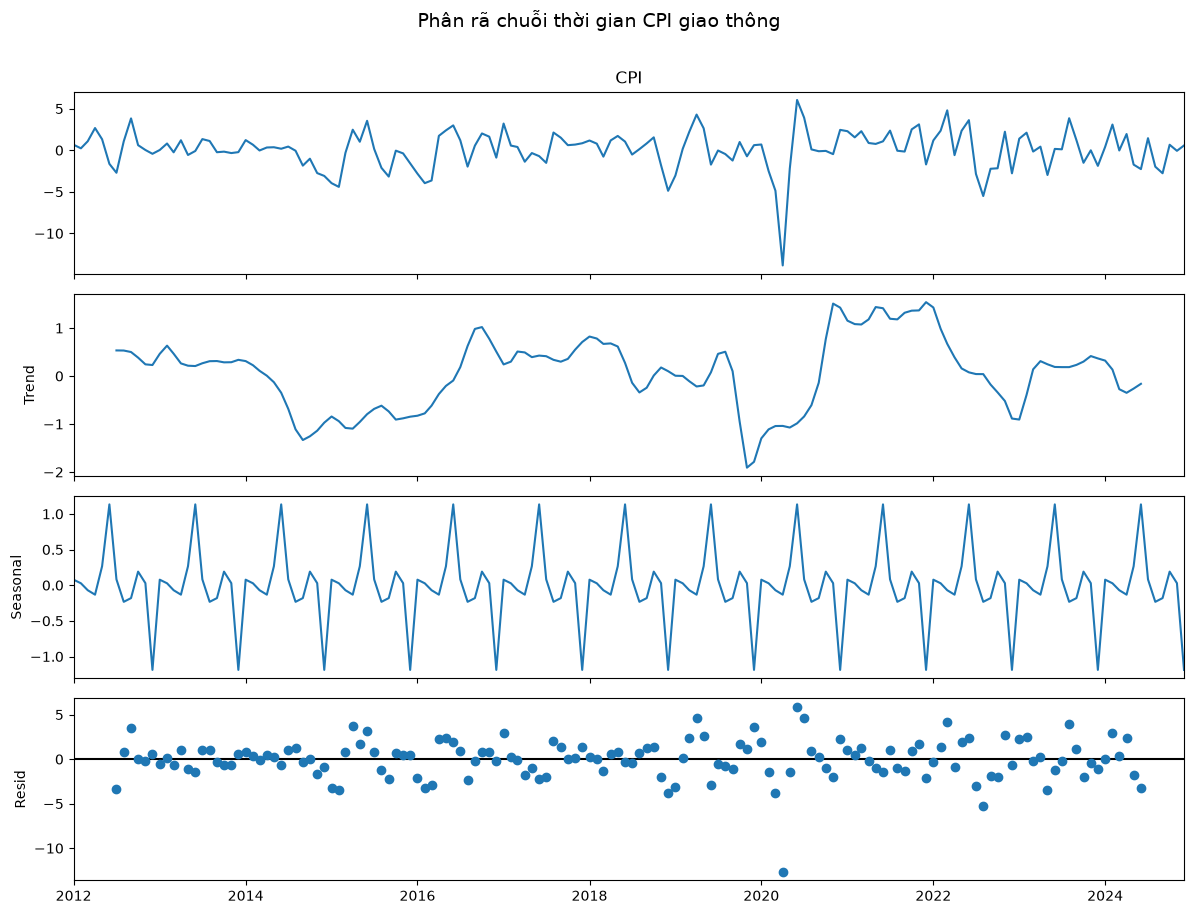

In [27]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Tạo chuỗi thời gian CPI
cpi_ts = df.copy()

cpi_ts["Date"] = cpi_ts["MonthYear"].dt.to_timestamp()

cpi_series = (
    cpi_ts
    .set_index("Date")["CPI"]
    .asfreq("MS")
)

# Phân rã chuỗi với chu kỳ 12 tháng
decomposition = seasonal_decompose(
    cpi_series,
    model="additive",
    period=12
)

fig = decomposition.plot()
fig.set_size_inches(12, 9)

plt.suptitle(
    "Phân rã chuỗi thời gian CPI giao thông",
    fontsize=14,
    y=1.01
)

plt.tight_layout()
plt.show()

In [28]:
seasonal_df = pd.DataFrame({
    "Month": decomposition.seasonal.index.month,
    "Seasonal": decomposition.seasonal.values
})

seasonal_by_month = (
    seasonal_df
    .groupby("Month")["Seasonal"]
    .mean()
    .round(2)
)

seasonal_by_month

Month
1     0.08
2     0.03
3    -0.07
4    -0.13
5     0.27
6     1.13
7     0.08
8    -0.23
9    -0.18
10    0.19
11    0.03
12   -1.19
Name: Seasonal, dtype: float64

In [32]:
june_cpi = df[
    df["MonthYear"].dt.month == 6
][["MonthYear", "CPI"]]

june_cpi

,MonthYear,CPI
5,2012-06,-1.64
17,2013-06,-0.09
29,2014-06,0.18
41,2015-06,3.54
53,2016-06,2.99
65,2017-06,-0.71
77,2018-06,1.04
89,2019-06,-1.73
101,2020-06,6.05
113,2021-06,1.07


### Nhận xét

Kết quả phân rã cho thấy CPI giao thông có **xu hướng thay đổi theo từng giai đoạn**, đồng thời tồn tại **mùa vụ theo tháng** và một số biến động bất thường.

Thành phần mùa vụ nổi bật nhất ở **tháng 6 (1,13)** và thấp nhất ở **tháng 12 (-1,19)**. Tuy nhiên, CPI tháng 6 không tăng ở tất cả các năm, nên đây chỉ được xem là mẫu hình mùa vụ trong dữ liệu.

Tháng 1 và tháng 2 có hiệu ứng mùa vụ khá nhỏ, vì Tết thay đổi giữa hai tháng này qua từng năm nên biến `Dummy_Tet` vẫn cần thiết để phản ánh riêng ảnh hưởng của Tết.

Phần dư chủ yếu dao động quanh 0 nhưng vẫn xuất hiện một số cú sốc lớn, đặc biệt quanh năm 2020.

### 10.2. Kiểm định tính dừng bằng ADF

Kiểm định Augmented Dickey-Fuller (ADF) được sử dụng để kiểm tra giả thuyết:

- **H0:** Chuỗi CPI không dừng.
- **H1:** Chuỗi CPI dừng.

Nếu `p-value < 0,05`, có thể bác bỏ H0 và xem chuỗi CPI là dừng.

In [23]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(df["CPI"].dropna())

print(f"ADF Statistic: {adf_result[0]:.4f}")
print(f"p-value: {adf_result[1]:.4f}")

print("\nCritical Values:")
for key, value in adf_result[4].items():
    print(f"{key}: {value:.4f}")

ADF Statistic: -8.7189
p-value: 0.0000

Critical Values:
1%: -3.4735
5%: -2.8805
10%: -2.5769


### Nhận xét

Kết quả kiểm định ADF cho thấy:

- **ADF Statistic = -8,7189**
- **p-value = 0,0000**

Do `p-value < 0,05`, bác bỏ giả thuyết H0 và kết luận chuỗi CPI nhóm Giao thông **có tính dừng**.

Ngoài ra, giá trị ADF Statistic nhỏ hơn các mức tới hạn 1%, 5% và 10%, tiếp tục củng cố kết luận trên.

Như vậy, chuỗi CPI hiện tại không cần sai phân thêm chỉ để đạt tính dừng trước khi tiếp tục phân tích ACF/PACF và xây dựng mô hình ARIMA.

### 10.3. Phân tích ACF và PACF

ACF và PACF được sử dụng để đánh giá mức độ phụ thuộc của CPI hiện tại vào các giá trị CPI trong quá khứ.

- **ACF (Autocorrelation Function):** đo mức tương quan giữa CPI hiện tại và CPI ở các độ trễ trước.
- **PACF (Partial Autocorrelation Function):** đo tương quan trực tiếp tại từng độ trễ sau khi loại ảnh hưởng của các độ trễ trung gian.

Kết quả ACF và PACF được sử dụng làm cơ sở tham khảo khi lựa chọn các tham số `p` và `q` cho mô hình ARIMA.

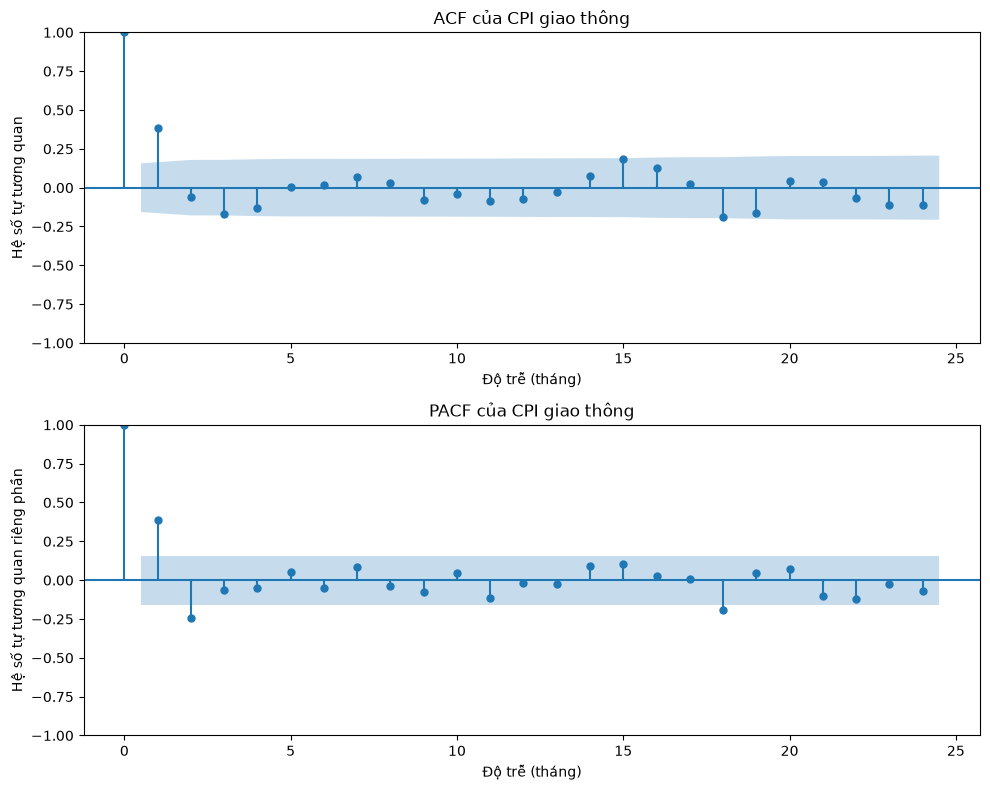

In [34]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

cpi_series = df["CPI"].dropna()

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

plot_acf(
    cpi_series,
    lags=24,
    ax=axes[0]
)

axes[0].set_title("ACF của CPI giao thông")
axes[0].set_xlabel("Độ trễ (tháng)")
axes[0].set_ylabel("Hệ số tự tương quan")

plot_pacf(
    cpi_series,
    lags=24,
    ax=axes[1],
    method="ywm"
)

axes[1].set_title("PACF của CPI giao thông")
axes[1].set_xlabel("Độ trễ (tháng)")
axes[1].set_ylabel("Hệ số tự tương quan riêng phần")

plt.tight_layout()
plt.show()

### Nhận xét

Biểu đồ ACF cho thấy tự tương quan nổi bật nhất tại **Lag 1**, trong khi các độ trễ sau phần lớn nằm trong khoảng tin cậy. PACF cho thấy **Lag 1 và Lag 2** là các độ trễ đáng chú ý, cho thấy CPI hiện tại chủ yếu chịu ảnh hưởng từ các giá trị CPI trong 1–2 tháng trước.

Không xuất hiện đỉnh rõ rệt tại Lag 12, do đó chưa ghi nhận cấu trúc tự tương quan mùa vụ 12 tháng mạnh.

Kết hợp với kiểm định ADF cho thấy chuỗi CPI đã dừng, các giá trị `p` và `q` ở bậc thấp sẽ được xem xét và lựa chọn tiếp dựa trên AIC/BIC và kiểm định phần dư của mô hình.

## 11. Kết luận phân tích khám phá dữ liệu

Kết quả EDA cho thấy CPI nhóm Giao thông có mức biến động đáng kể theo thời gian và chịu ảnh hưởng rõ hơn từ biến động giá nhiên liệu trong nước.

Biến động giá **RON95** và **Diesel** có mối liên hệ đáng kể với CPI, trong khi **Brent** và **WTI** thể hiện ảnh hưởng rõ hơn ở độ trễ khoảng 1 tháng. Tỷ giá **USD/VND** có tương quan tương đối yếu với CPI trong giai đoạn nghiên cứu.

Chuỗi CPI có tính dừng theo kiểm định ADF, đồng thời tồn tại một số đặc điểm mùa vụ và các biến động bất thường. ACF và PACF cho thấy CPI hiện tại chủ yếu có quan hệ với các giá trị trong khoảng 1–2 tháng trước.

Các kết quả trên sẽ được sử dụng làm cơ sở cho bước **xây dựng đặc trưng và lựa chọn biến đầu vào cho mô hình dự báo**.